# Feature Scaling

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/01-data-preprocessing/03_feature_scaling.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Why some features dominate others
- Normalization vs Standardization
- When to use which scaling
- Common scaling mistakes

## Why This Matters

Features with different scales break ML models.

**Example:** House price prediction
```
Size: 1000-5000 sq ft
Bedrooms: 1-5
```

**Problem:** Model thinks "Size" is 1000× more important than "Bedrooms"!

**Solution:** Scale both to [0, 1] or mean=0, std=1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.datasets import make_regression

np.random.seed(42)
print("Feature Scaling: Making Features Play Fair")

Feature Scaling: Making Features Play Fair


---
## 1. Create Unscaled Data

In [2]:
# House dataset with different scales
np.random.seed(42)

data = {
    'house_id': range(1, 21),
    'size_sqft': np.random.randint(800, 5000, 20),      # 800-5000
    'bedrooms': np.random.randint(1, 6, 20),            # 1-5
    'age_years': np.random.randint(0, 50, 20),          # 0-50
    'price': np.random.randint(100000, 800000, 20)      # $100k-$800k
}

df = pd.DataFrame(data)
print("House Dataset (Unscaled):")
print(df.head(10))
print(f"\nShape: {df.shape}")

House Dataset (Unscaled):
   house_id  size_sqft  bedrooms  age_years   price
0         1       1660         4          1  538974
1         2       4572         4         19  302283
2         3       3892         3         27  296769
3         4       1266         4         46  661353
4         5       4244         4          6  323165
5         6       3971         1         43  723587
6         7       3719         3          7  635822
7         8        930         5         46  587879
8         9       2485         3         34  664685
9        10       1569         5         13  453531

Shape: (20, 5)


In [3]:
# Check ranges
print("\nFeature Ranges (BIG DIFFERENCE!):")
print("="*50)
for col in ['size_sqft', 'bedrooms', 'age_years']:
    print(f"{col:15} : {df[col].min():8.2f} to {df[col].max():8.2f}")

print("\n⚠️ Size is 1000× bigger than Bedrooms!")
print("   Models will focus on Size, ignore Bedrooms")


Feature Ranges (BIG DIFFERENCE!):
size_sqft       :   930.00 to  4917.00
bedrooms        :     1.00 to     5.00
age_years       :     1.00 to    49.00

⚠️ Size is 1000× bigger than Bedrooms!
   Models will focus on Size, ignore Bedrooms


---
## 2. Visualize the Problem

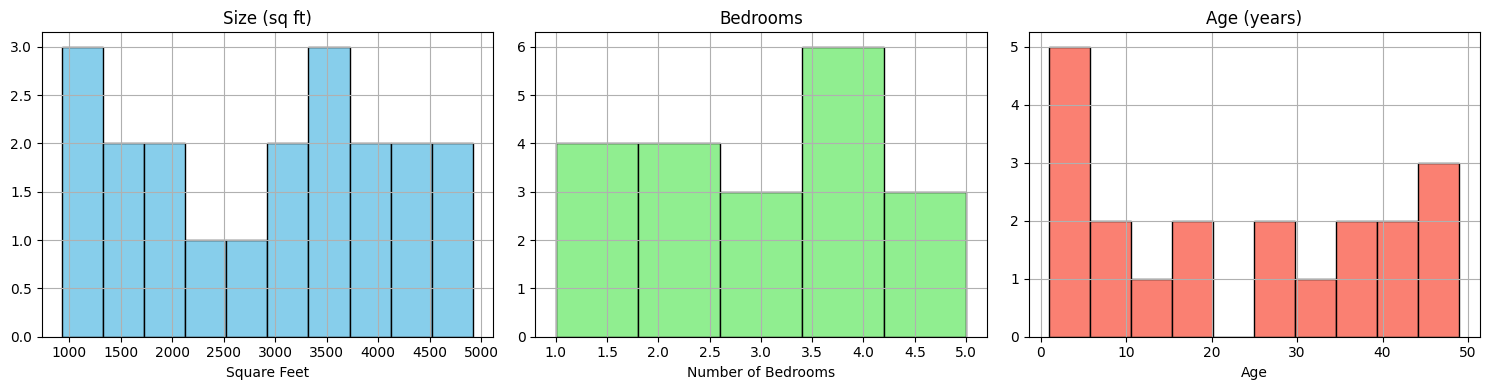

Notice: All features on DIFFERENT scales


In [4]:
# Plot unscaled features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['size_sqft'].hist(bins=10, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Size (sq ft)')
axes[0].set_xlabel('Square Feet')

df['bedrooms'].hist(bins=5, ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Bedrooms')
axes[1].set_xlabel('Number of Bedrooms')

df['age_years'].hist(bins=10, ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Age (years)')
axes[2].set_xlabel('Age')

plt.tight_layout()
plt.show()

print("Notice: All features on DIFFERENT scales")

---
## 3. Min-Max Normalization (0-1)

In [5]:
# Min-Max Scaling: Squeeze to [0, 1]
# Formula: (X - min) / (max - min)

df_minmax = df.copy()
scaler_minmax = MinMaxScaler()

features = ['size_sqft', 'bedrooms', 'age_years']
df_minmax[features] = scaler_minmax.fit_transform(df_minmax[features])

print("Min-Max Scaled (0 to 1):")
print(df_minmax[features].head(10))

print("\n" + "="*50)
print("New Ranges:")
print("="*50)
for col in features:
    print(f"{col:15} : {df_minmax[col].min():.4f} to {df_minmax[col].max():.4f}")

print("\n✅ USE Min-Max when:")
print("  - Neural Networks")
print("  - Image processing (pixel values)")
print("  - Need values in [0, 1]")
print("\n❌ DON'T USE when:")
print("  - Outliers present (they'll squeeze everything)")

Min-Max Scaled (0 to 1):
   size_sqft  bedrooms  age_years
0   0.183095      0.75   0.000000
1   0.913469      0.75   0.375000
2   0.742914      0.50   0.541667
3   0.084274      0.75   0.937500
4   0.831201      0.75   0.104167
5   0.762729      0.00   0.875000
6   0.699523      0.50   0.125000
7   0.000000      1.00   0.937500
8   0.390018      0.50   0.687500
9   0.160271      1.00   0.250000

New Ranges:
size_sqft       : 0.0000 to 1.0000
bedrooms        : 0.0000 to 1.0000
age_years       : 0.0000 to 1.0000

✅ USE Min-Max when:
  - Neural Networks
  - Image processing (pixel values)
  - Need values in [0, 1]

❌ DON'T USE when:
  - Outliers present (they'll squeeze everything)


---
## 4. Standardization (Z-score)

In [6]:
# Standardization: Mean=0, Std=1
# Formula: (X - mean) / std

df_standard = df.copy()
scaler_standard = StandardScaler()

df_standard[features] = scaler_standard.fit_transform(df_standard[features])

print("Standardized (Mean=0, Std=1):")
print(df_standard[features].head(10))

print("\n" + "="*50)
print("Statistics:")
print("="*50)
print(df_standard[features].describe().loc[['mean', 'std']])

print("\n✅ USE Standardization when:")
print("  - Linear models (Linear/Logistic Regression)")
print("  - SVM")
print("  - PCA")
print("  - Data is normally distributed")
print("\n❌ DON'T USE when:")
print("  - Tree-based models (they don't need it)")

Standardized (Mean=0, Std=1):
   size_sqft  bedrooms  age_years
0  -1.072168  0.725476  -1.295325
1   1.359131  0.725476  -0.240309
2   0.791383  0.000000   0.228587
3  -1.401128  0.725476   1.342214
4   1.085276  0.725476  -1.002265
5   0.857342 -1.450953   1.166378
6   0.646941  0.000000  -0.943653
7  -1.681662  1.450953   1.342214
8  -0.383355  0.000000   0.638871
9  -1.148146  1.450953  -0.591981

Statistics:
         size_sqft  bedrooms     age_years
mean -7.910339e-17  0.000000 -7.771561e-17
std   1.025978e+00  1.025978  1.025978e+00

✅ USE Standardization when:
  - Linear models (Linear/Logistic Regression)
  - SVM
  - PCA
  - Data is normally distributed

❌ DON'T USE when:
  - Tree-based models (they don't need it)


---
## 5. Robust Scaling (Handles Outliers)

In [7]:
# Add outliers to show difference
df_outlier = df.copy()
df_outlier.loc[0, 'size_sqft'] = 15000  # Outlier: Mansion!

print("Added Outlier:")
print(df_outlier[['size_sqft', 'bedrooms', 'age_years']].head())
print(f"\nSize range: {df_outlier['size_sqft'].min()} - {df_outlier['size_sqft'].max()}")

Added Outlier:
   size_sqft  bedrooms  age_years
0      15000         4          1
1       4572         4         19
2       3892         3         27
3       1266         4         46
4       4244         4          6

Size range: 930 - 15000


In [8]:
# Compare scalers with outlier
df_minmax_outlier = df_outlier.copy()
df_robust_outlier = df_outlier.copy()

scaler_robust = RobustScaler()

# Min-Max (affected by outlier)
df_minmax_outlier[features] = MinMaxScaler().fit_transform(df_minmax_outlier[features])

# Robust (uses median/IQR, not affected)
df_robust_outlier[features] = scaler_robust.fit_transform(df_robust_outlier[features])

print("Min-Max with Outlier:")
print(df_minmax_outlier[features].head())
print(f"\nMost values squashed near 0! (outlier at {df_minmax_outlier.loc[0, 'size_sqft']:.4f})")

print("\n" + "="*50)
print("Robust Scaler with Outlier:")
print(df_robust_outlier[features].head())
print("\nValues well-distributed! Outlier handled gracefully.")

print("\n✅ USE Robust when:")
print("  - Outliers present")
print("  - Financial data (extreme values common)")

Min-Max with Outlier:
   size_sqft  bedrooms  age_years
0   1.000000      0.75   0.000000
1   0.258849      0.75   0.375000
2   0.210519      0.50   0.541667
3   0.023881      0.75   0.937500
4   0.235537      0.75   0.104167

Most values squashed near 0! (outlier at 1.0000)

Robust Scaler with Outlier:
   size_sqft  bedrooms  age_years
0   5.665295       0.5  -0.651852
1   0.617861       0.5  -0.118519
2   0.288722       0.0   0.118519
3  -0.982333       0.5   0.681481
4   0.459100       0.5  -0.503704

Values well-distributed! Outlier handled gracefully.

✅ USE Robust when:
  - Outliers present
  - Financial data (extreme values common)


---
## 6. Compare All Scalers

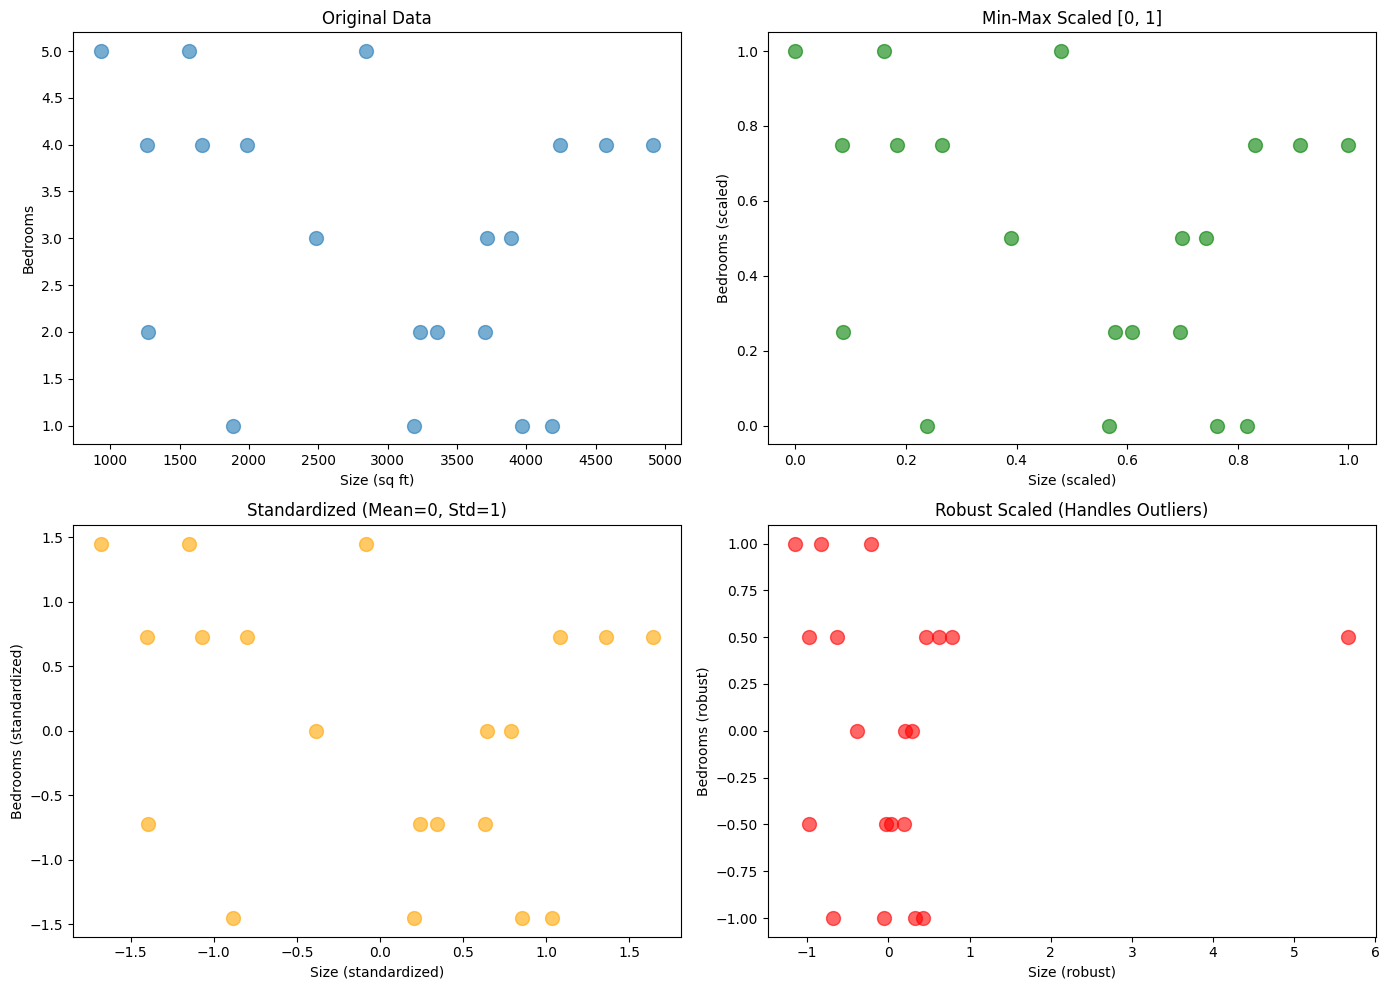

Notice: Shape preserved, scales equalized!


In [9]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original
axes[0, 0].scatter(df['size_sqft'], df['bedrooms'], alpha=0.6, s=100)
axes[0, 0].set_title('Original Data')
axes[0, 0].set_xlabel('Size (sq ft)')
axes[0, 0].set_ylabel('Bedrooms')

# Min-Max
axes[0, 1].scatter(df_minmax['size_sqft'], df_minmax['bedrooms'], alpha=0.6, s=100, color='green')
axes[0, 1].set_title('Min-Max Scaled [0, 1]')
axes[0, 1].set_xlabel('Size (scaled)')
axes[0, 1].set_ylabel('Bedrooms (scaled)')

# Standardized
axes[1, 0].scatter(df_standard['size_sqft'], df_standard['bedrooms'], alpha=0.6, s=100, color='orange')
axes[1, 0].set_title('Standardized (Mean=0, Std=1)')
axes[1, 0].set_xlabel('Size (standardized)')
axes[1, 0].set_ylabel('Bedrooms (standardized)')

# Robust
axes[1, 1].scatter(df_robust_outlier['size_sqft'], df_robust_outlier['bedrooms'], alpha=0.6, s=100, color='red')
axes[1, 1].set_title('Robust Scaled (Handles Outliers)')
axes[1, 1].set_xlabel('Size (robust)')
axes[1, 1].set_ylabel('Bedrooms (robust)')

plt.tight_layout()
plt.show()

print("Notice: Shape preserved, scales equalized!")

---
## 7. Common Mistake: Data Leakage

In [10]:
# ❌ WRONG: Scale entire dataset first, then split
from sklearn.model_selection import train_test_split

# BAD CODE:
df_wrong = df.copy()
df_wrong[features] = StandardScaler().fit_transform(df_wrong[features])  # ❌ Scaled ALL data
X_train_wrong, X_test_wrong = train_test_split(df_wrong[features], test_size=0.2)

print("❌ WRONG: Test data influenced training!")
print("   (Scaler saw test data mean/std)")

print("\n" + "="*50)

# ✅ CORRECT: Split first, then scale
X = df[features]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Fit on training, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # ✅ Fit on train only
X_test_scaled = scaler.transform(X_test)         # ✅ Transform test

print("✅ CORRECT: Test data never seen during fit!")
print(f"\nTrain shape: {X_train_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")

print("\n⚠️ NEVER fit() on test data!")

❌ WRONG: Test data influenced training!
   (Scaler saw test data mean/std)

✅ CORRECT: Test data never seen during fit!

Train shape: (16, 3)
Test shape: (4, 3)

⚠️ NEVER fit() on test data!


---
## 8. Model-Specific Guide

| Model | Need Scaling? | Recommended Method |
|-------|---------------|--------------------|
| Linear Regression | ✅ Yes | Standardization |
| Logistic Regression | ✅ Yes | Standardization |
| Neural Networks | ✅ Yes | Min-Max or Standardization |
| SVM | ✅ **Critical!** | Standardization |
| KNN | ✅ Yes | Min-Max |
| Random Forest | ❌ No | None needed |
| XGBoost | ❌ No | None needed |
| Decision Trees | ❌ No | None needed |
| Naive Bayes | ❌ No | None needed |

**Why tree models don't need scaling?**
- They split on thresholds (e.g., Age > 30)
- Scale doesn't matter for comparisons

---
## Decision Tree: Which Scaler?

```
Is model tree-based (Random Forest, XGBoost)?
  YES → NO SCALING NEEDED!
  
  NO → Continue
  
Do you have outliers?
  YES → Robust Scaler
  
  NO → Continue
  
Need values in [0, 1]?
  YES → Min-Max
  
  NO → Standardization
```

---
## Key Takeaways

1. **Scale when features have different ranges**
2. **Min-Max** for [0, 1] range (neural nets)
3. **Standardization** for mean=0, std=1 (linear models)
4. **Robust** for outliers
5. **Split FIRST, then scale** (avoid data leakage)
6. **fit() on train, transform() on test**
7. **Tree models don't need scaling**

**Most common**: Standardization (works for most models)

---
## Your Turn

1. Load a dataset with different feature scales
2. Visualize before/after scaling
3. Try all 3 scalers
4. Check: Did you split before scaling?

In [11]:
# Your code here